In [20]:
import torch
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
from datasets import (
    Dataset,
    Features,
    Value,
    Image as HfImage,
    load_dataset,
    concatenate_datasets,
)
from PIL import Image as PilImage, ImageDraw, ImageFont
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torchvision

## Helper functions

In [21]:
def visualize_detections_matplotlib(image, detections):
    """Visualize detections on the image using matplotlib.
    Args:
        image (PIL.Image or np.array): The input image.
        detections (list of dict): List of detections, each a dict with keys
            'box' (list of [x_min, y_min, x_max, y_max]), 'label' (str), and 'score' (float).
    """
    fig, ax = plt.subplots(1, figsize=(12, 8))
    ax.imshow(image)

    # Color map for different labels
    colors = plt.cm.tab10(np.linspace(0, 1, 10))
    label_to_color = {}

    for i, det in enumerate(detections):
        box = det["box"]  # [x_min, y_min, x_max, y_max]
        label = det["label"]
        score = det["score"]

        # Assign color
        if label not in label_to_color:
            label_to_color[label] = colors[len(label_to_color) % 10]
        color = label_to_color[label]

        # Draw bounding box
        x_min, y_min, x_max, y_max = box
        width = x_max - x_min
        height = y_max - y_min

        rect = patches.Rectangle(
            (x_min, y_min), width, height,
            linewidth=3, edgecolor=color, facecolor='none'
        )
        ax.add_patch(rect)

        # Add label text
        label_text = f"{label}: {score:.2f}"
        ax.text(
            x_min, y_min - 5,
            label_text,
            bbox=dict(boxstyle='round,pad=0.5', facecolor=color, alpha=0.7),
            fontsize=10, color='white', weight='bold'
        )

    ax.axis('off')
    plt.tight_layout()
    plt.show()

In [22]:
def box_cxcywh_to_xyxy(boxes):
    """Convert boxes from [cx, cy, w, h] to [x1, y1, x2, y2] format"""
    x_c, y_c, w, h = boxes.unbind(-1)
    b = [
        (x_c - 0.5 * w),
        (y_c - 0.5 * h),
        (x_c + 0.5 * w),
        (y_c + 0.5 * h)
    ]
    return torch.stack(b, dim=-1)

In [23]:
def custom_nms(boxes, scores, iou_threshold=0.5):
    """
    Apply Non-Maximum Suppression

    Args:
        boxes: [N, 4] tensor in [x1, y1, x2, y2] format (normalized 0-1)
        scores: [N] tensor of confidence scores
        iou_threshold: IoU threshold for suppression

    Returns:
        keep_indices: indices of boxes to keep
    """
    if len(boxes) == 0:
        return torch.tensor([])

    # Use torchvision's NMS
    keep = torchvision.ops.nms(boxes, scores, iou_threshold)
    return keep

## Load the dataset

In [24]:
!kaggle datasets download -d aryashah2k/breast-ultrasound-images-dataset -p ../data --unzip

Dataset URL: https://www.kaggle.com/datasets/aryashah2k/breast-ultrasound-images-dataset
License(s): CC0-1.0
 67%|██████████████████████████▉             | 131M/195M [00:00<00:00, 1.37GB/s]
100%|████████████████████████████████████████| 195M/195M [00:00<00:00, 1.38GB/s]


In [25]:
base_dir = "../data/Dataset_BUSI_with_GT/"

records = []
for label in ["benign", "malignant", "normal"]:
    folder = os.path.join(base_dir, label)
    for file in os.listdir(folder):
        if not file.endswith(".png") or "mask" in file:
            continue

        img_path = os.path.join(folder, file)

        # Find all masks for this image
        base_name = file.replace(".png", "")
        mask_files = [
            f for f in os.listdir(folder) if f.startswith(base_name + "_mask")
        ]

        if mask_files:
            masks = []
            for m in mask_files:
                mask_img = np.array(PilImage.open(
                    os.path.join(folder, m)).convert("L"))
                masks.append(mask_img > 0)

            merged_mask = np.any(masks, axis=0).astype(np.uint8) * 255
            conditioning_image = PilImage.fromarray(merged_mask)
        else:
            conditioning_image_path = None

        records.append(
            {
                "image": img_path,  # just the path
                "conditioning_image": conditioning_image,  # PIL Image or None
                "caption": label,
            }
        )

# Define features so Hugging Face knows how to decode them
features = Features(
    {"image": HfImage(), "conditioning_image": HfImage(), "caption": Value("string")}
)

kaggle_dataset = Dataset.from_list(records, features=features)

hf = load_dataset("Amss007/ultrasound_dataset_v3_1", cache_dir="../data")

features = Features(
    {"image": HfImage(), "conditioning_image": HfImage(), "caption": Value("string")}
)

# Cast Kaggle dataset
kaggle_dataset = kaggle_dataset.cast(features, num_proc=4)

hf_dataset = hf["train"]  # flatten to Dataset
hf_dataset = hf_dataset.cast(features)

merged_dataset = concatenate_datasets([kaggle_dataset, hf_dataset])

print(merged_dataset)

Casting the dataset (num_proc=4):   0%|          | 0/780 [00:00<?, ? examples/s]

Dataset({
    features: ['image', 'conditioning_image', 'caption'],
    num_rows: 4765
})


## Take a sample example

In [26]:
sample = merged_dataset[1]          # take the first example
image = sample["image"]             # PIL Image

# prompts = ["benign", "malignant", "tumor", "only one circular patch", sample['caption']]  # manual prompts
# prompts = ["only one circular patch", sample['caption']]  # Gave better results
prompts = ["only one circular patch which is " +
           sample['caption']]  # manual prompts

## Load the model, processor

In [27]:

# Set device (GPU if available, else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Tiny Swin-T checkpoint trained on O365+GoldG+GRIT+V3Det
# model_id = "openmmlab-community/mm_grounding_dino_tiny_o365v1_goldg_grit_v3det"
# model_id = "openmmlab-community/mm_grounding_dino_tiny_o365v1_goldg_v3det"
model_id = "IDEA-Research/grounding-dino-tiny"

# This handles all preprocessing for images + text
processor = AutoProcessor.from_pretrained(model_id, use_fast=False)

# This is the object detection model that predicts bounding boxes and labels
model = AutoModelForZeroShotObjectDetection.from_pretrained(
    model_id).to(device)

# Preprocess image + text
inputs = processor(
    images=image,
    text=prompts,
    return_tensors="pt"
)

# Move inputs to the same device as model
inputs = {k: v.to(device) if hasattr(v, "to") else v for k, v in inputs.items()}

# Forward pass
with torch.no_grad():
    outputs = model(**inputs)

# Inspect outputs
print(outputs.keys())

Using device: cuda


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

odict_keys(['logits', 'pred_boxes', 'last_hidden_state', 'init_reference_points', 'intermediate_hidden_states', 'intermediate_reference_points', 'encoder_last_hidden_state_vision', 'encoder_last_hidden_state_text', 'enc_outputs_class', 'enc_outputs_coord_logits', 'encoder_logits', 'encoder_pred_boxes', 'input_ids'])


### Using Raw Outputs to get bounding boxes

Detected class 4 with score 0.38 at [300.0, 93.0, 412.0, 164.0]
Detected class 7 with score 0.30 at [0.0, 0.0, 544.0, 469.0]


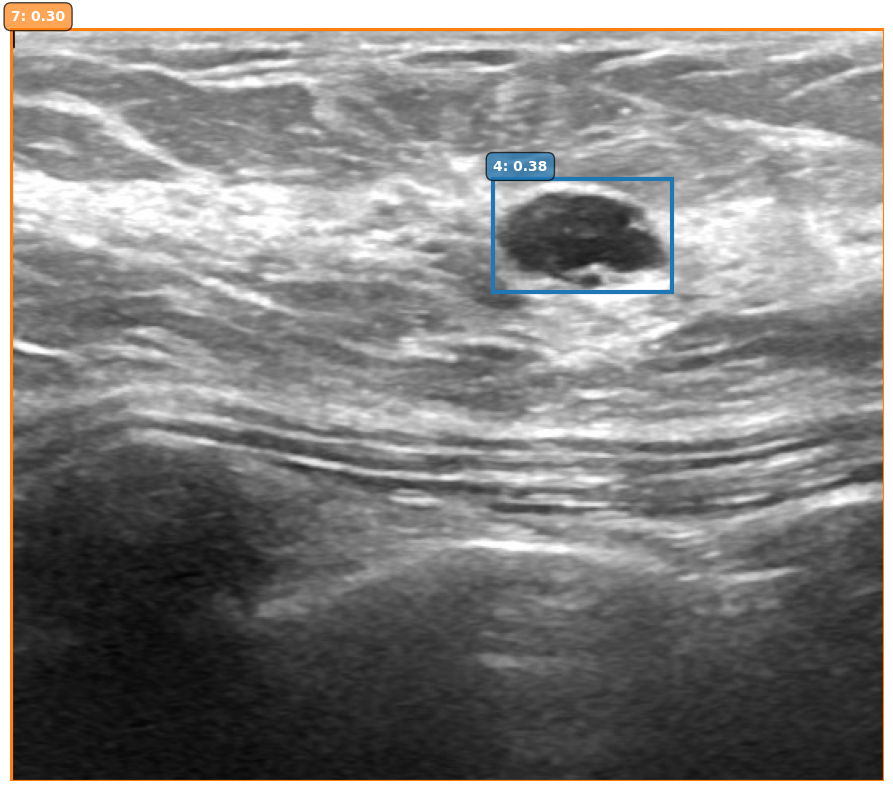

In [28]:
pred_logits = outputs.logits[0]       # [1, num_queries, num_classes] so taking 1st element
pred_boxes = outputs.pred_boxes[0]   # [1, num_queries, 4], normalized so taking 1st element

threshold = 0.3
probs = pred_logits.softmax(-1)[:, :-1]  # ignore last "no-object" class
scores, labels = probs.max(-1)              # max probability per query
mask = scores > threshold

filtered_boxes_normalized  = pred_boxes[mask]
filtered_scores = scores[mask]
filtered_labels = labels[mask]

width, height = image.size
boxes_corner = filtered_boxes_normalized.clone()
boxes_corner[:, 0] = (filtered_boxes_normalized[:, 0] - filtered_boxes_normalized[:, 2] / 2) * width   # x0
boxes_corner[:, 1] = (filtered_boxes_normalized[:, 1] - filtered_boxes_normalized[:, 3] / 2) * height  # y0
boxes_corner[:, 2] = (filtered_boxes_normalized[:, 0] + filtered_boxes_normalized[:, 2] / 2) * width   # x1
boxes_corner[:, 3] = (filtered_boxes_normalized[:, 1] + filtered_boxes_normalized[:, 3] / 2) * height  # y1

# Print results
filtered_detections = []
for box, score, label in zip(boxes_corner, filtered_scores, filtered_labels):
    x1, y1, x2, y2 = map(lambda x:round(x), box.tolist())
    filtered_detections.append({
            "label": label,
            "score": score.item(),
            "box": box.tolist()
        })
    print(
        f"Detected class {label.item()} with score {score.item():.2f} at [{x1:.1f}, {y1:.1f}, {x2:.1f}, {y2:.1f}]")
    
visualize_detections_matplotlib(image, filtered_detections)

### Using official post processor to get bounding boxes

Detected: one circular patch with confidence 0.58

Total detections above threshold: 1


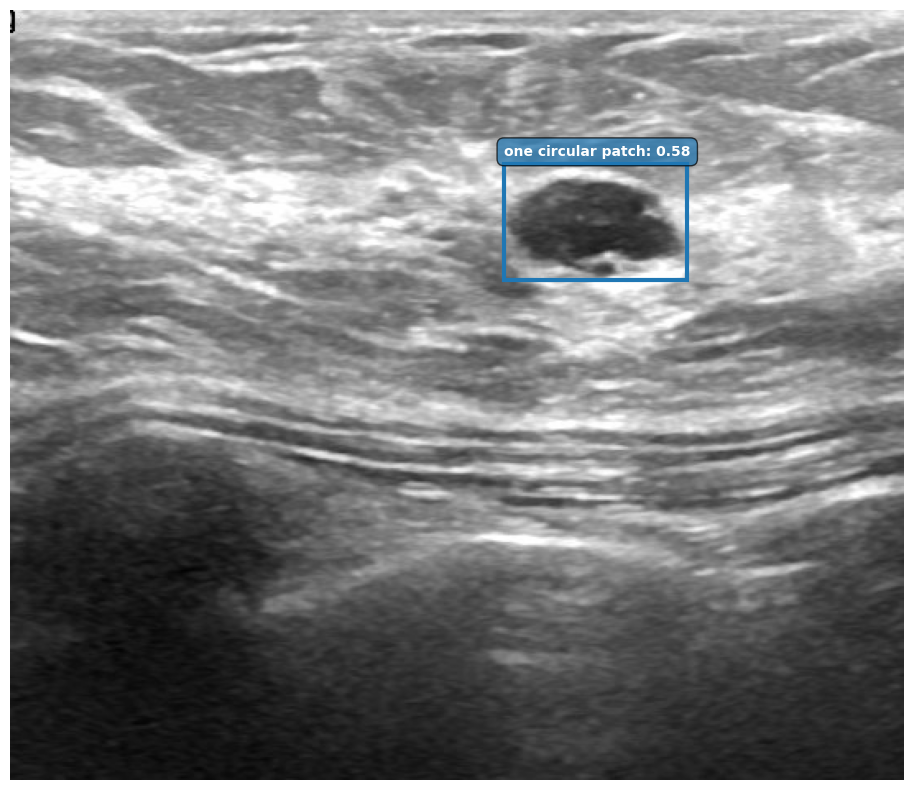

In [29]:
# Post-process
results = processor.post_process_grounded_object_detection(
    outputs,
    inputs['input_ids'],
    target_sizes=[image.size[::-1]]
)

# Now filter by thresholds manually
threshold = 0.3  # Adjust as needed

post_labels = results[0]["text_labels"]
post_scores = results[0]["scores"]
post_boxes = results[0]["boxes"]

filtered_detections = []
for label, score, box in zip(post_labels, post_scores, post_boxes):
    if score >= threshold:
        filtered_detections.append({
            "label": label,
            "score": score.item(),
            "box": box.tolist()
        })
        print(f"Detected: {label} with confidence {score:.2f}")

# Use the visualization methods
print(f"\nTotal detections above threshold: {len(filtered_detections)}")

# # Visualize with matplotlib
visualize_detections_matplotlib(image, filtered_detections)

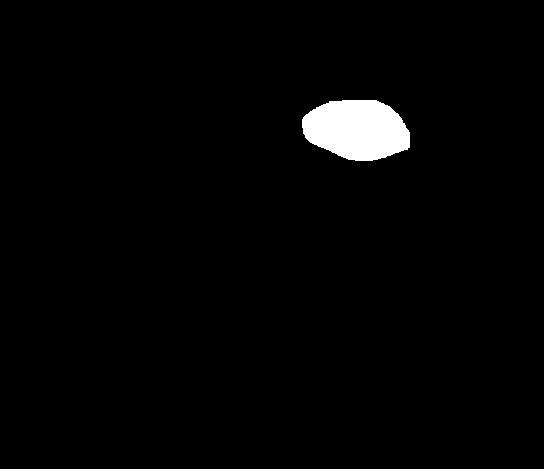

In [30]:
sample["conditioning_image"]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Detections before NMS: 2
Detections after NMS (IoU=0.5): 2

Final Detections:
  1. Class 4 - Score: 0.378
     Box: [300.4, 93.3, 411.7, 164.1]
  2. Class 7 - Score: 0.301
     Box: [0.1, 0.0, 544.1, 469.0]


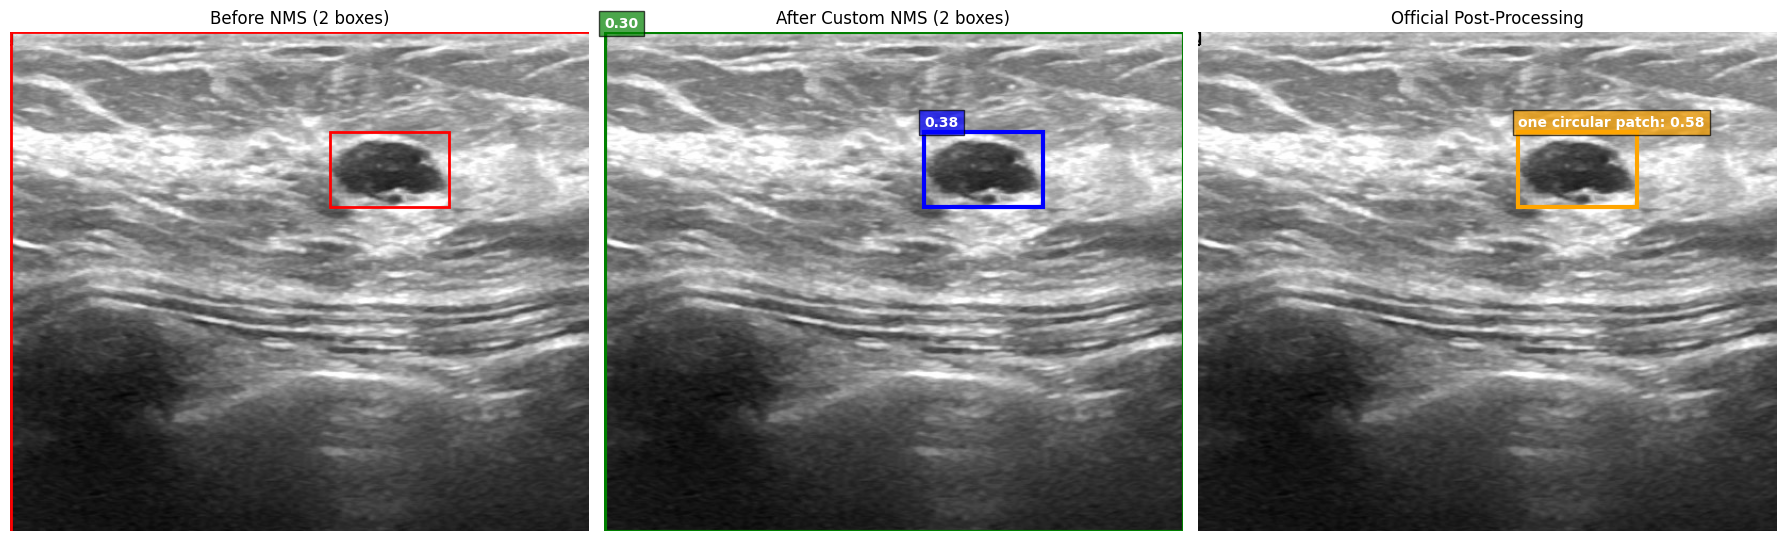


Try different IoU thresholds to see the effect:
IoU threshold 0.3: 2 boxes remaining
IoU threshold 0.5: 2 boxes remaining
IoU threshold 0.7: 2 boxes remaining


In [31]:
# Load model
model_id = "IDEA-Research/grounding-dino-tiny"
processor = AutoProcessor.from_pretrained(model_id)
model = AutoModelForZeroShotObjectDetection.from_pretrained(model_id)

sample = merged_dataset[1]  # take the first example
image = sample["image"]  # PIL Image

prompts = ["only one circular patch which is " + sample["caption"]]  # manual prompts

# Run inference
inputs = processor(images=image, text=prompts, return_tensors="pt")
with torch.no_grad():
    outputs = model(**inputs)

# Get raw predictions
pred_logits = outputs.logits[0]  # [num_queries, num_classes]
pred_boxes = outputs.pred_boxes[0]  # [num_queries, 4] in [cx, cy, w, h] format

# Apply confidence threshold
confidence_threshold = 0.3
probs = pred_logits.softmax(-1)[:, :-1]  # ignore "no-object" class
scores, labels = probs.max(-1)
mask = scores > confidence_threshold

filtered_boxes_cxcywh = pred_boxes[mask]  # Still in center format
filtered_scores = scores[mask]
filtered_labels = labels[mask]

print(f"Detections before NMS: {len(filtered_boxes_cxcywh)}")

# Convert to corner format for NMS
filtered_boxes_xyxy = box_cxcywh_to_xyxy(filtered_boxes_cxcywh)

# Apply custom NMS with adjustable IoU threshold
iou_threshold = 0.5  # Adjust this: lower = more aggressive merging, higher = keep more boxes
keep_indices = custom_nms(filtered_boxes_xyxy, filtered_scores, iou_threshold=iou_threshold)

# Get final detections
final_boxes_xyxy = filtered_boxes_xyxy[keep_indices]
final_scores = filtered_scores[keep_indices]
final_labels = filtered_labels[keep_indices]

print(f"Detections after NMS (IoU={iou_threshold}): {len(final_boxes_xyxy)}")

# Convert to pixel coordinates
final_boxes_pixel = final_boxes_xyxy.clone()
final_boxes_pixel[:, [0, 2]] *= width   # x coordinates
final_boxes_pixel[:, [1, 3]] *= height  # y coordinates

# Print results
print("\nFinal Detections:")
for i, (box, score, label) in enumerate(zip(final_boxes_pixel, final_scores, final_labels)):
    x1, y1, x2, y2 = box.tolist()
    print(f"  {i+1}. Class {label.item()} - Score: {score:.3f}")
    print(f"     Box: [{x1:.1f}, {y1:.1f}, {x2:.1f}, {y2:.1f}]")

# ==================== VISUALIZATION ====================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Raw predictions (before NMS)
ax1 = axes[0]
ax1.imshow(image)
ax1.set_title(f"Before NMS ({len(filtered_boxes_cxcywh)} boxes)")
for box_xyxy in filtered_boxes_xyxy:
    x1, y1, x2, y2 = box_xyxy.tolist()
    x1, y1, x2, y2 = x1*width, y1*height, x2*width, y2*height
    rect = patches.Rectangle(
        (x1, y1), x2-x1, y2-y1,
        linewidth=2, edgecolor='red', facecolor='none'
    )
    ax1.add_patch(rect)
ax1.axis('off')

# 2. After custom NMS
ax2 = axes[1]
ax2.imshow(image)
ax2.set_title(f"After Custom NMS ({len(final_boxes_pixel)} boxes)")
colors = ['blue', 'green', 'cyan', 'magenta', 'yellow']
for i, (box, score) in enumerate(zip(final_boxes_pixel, final_scores)):
    x1, y1, x2, y2 = box.tolist()
    color = colors[i % len(colors)]
    rect = patches.Rectangle(
        (x1, y1), x2-x1, y2-y1,
        linewidth=3, edgecolor=color, facecolor='none'
    )
    ax2.add_patch(rect)
    ax2.text(x1, y1-5, f"{score:.2f}", 
            bbox=dict(facecolor=color, alpha=0.7),
            fontsize=10, color='white', weight='bold')
ax2.axis('off')

# 3. Official post-processing (for comparison)
ax3 = axes[2]
ax3.imshow(image)
ax3.set_title("Official Post-Processing")
try:
    results = processor.post_process_grounded_object_detection(
        outputs,
        inputs.input_ids,
        target_sizes=[image.size[::-1]]
    )
    official_boxes = results[0]["boxes"]
    official_scores = results[0]["scores"]
    official_labels = results[0]["labels"]
    
    for box, score, label in zip(official_boxes, official_scores, official_labels):
        if score >= confidence_threshold:
            x1, y1, x2, y2 = box.tolist()
            rect = patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=3, edgecolor='orange', facecolor='none'
            )
            ax3.add_patch(rect)
            ax3.text(x1, y1-5, f"{label}: {score:.2f}", 
                    bbox=dict(facecolor='orange', alpha=0.7),
                    fontsize=10, color='white', weight='bold')
except Exception as e:
    ax3.text(0.5, 0.5, f"Official processing error:\n{str(e)}", 
            ha='center', va='center', transform=ax3.transAxes)
ax3.axis('off')

plt.tight_layout()
plt.show()

# ==================== ADJUSTING NMS THRESHOLD ====================
print("\n" + "="*60)
print("Try different IoU thresholds to see the effect:")
print("="*60)

for iou_thresh in [0.3, 0.5, 0.7]:
    keep = custom_nms(filtered_boxes_xyxy, filtered_scores, iou_threshold=iou_thresh)
    print(f"IoU threshold {iou_thresh}: {len(keep)} boxes remaining")